# Neural Networks 
In this model, two training methods are explored:
1. Baseline Training with SGD 
2. Optimised Training with Adam Optimiser

Upon the training, parameter tunning is then performed to optimise the performance. 

# Section 0: Load the Training Data + Initialisation

## 0.1 Data Loading 

In [17]:
# Load the training data.
Data_path="final_clean_train_df.csv"
target_column="readmitted"
train_df = pd.read_csv(Data_path)
print("Data loaded successfully.")
print("Training data shape:", train_df.shape)
print("Target column:", target_column)
print("columns:", list(train_df.columns))
train_df.head()

Data loaded successfully.
Training data shape: (91589, 180)
Target column: readmitted
columns: ['patient_nbr', 'age', 'is_weight_recorded', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'A1Cresult_not_recorded', 'max_glu_serum_not_recorded', 'A1Cresult_recorded', 'max_glu_serum_recorded', 'race_Caucasian', 'race_AfricanAmerican', 'race_Other', 'race_Hispanic', 'race_Asian', 'gender_Female', 'gender_Unknown/Invalid', 'admission_type_id_1', 'admission_type_id_2', 'admission_type_id_3', 'admission_type_id_6', 'admission_type_id_4', 'admission_type_id_5', 'admission_type_id_8', 'admission_type_id_7', 'discharge_disposition_id_1', 'discharge_disposition_id_3', 'discharge_disposition_id_6', 'discharge_disposition_id_2', 'discharge_disposition_id_5', 'discharge_disposition_id_11', 'discharge_disposition_id_7', 'discharge_disposition_id_25', 'discharge_disposition_id_10', 'discharg

,patient_nbr,age,is_weight_recorded,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,number_emergency_log,number_emergency_sqrt,num_medications_log,number_inpatient_log,number_inpatient_sqrt,num_medications_sqrt,time_in_hospital_log,time_in_hospital_sqrt,num_procedures_log,num_procedures_sqrt
0,55629189,15,0,3,59,0,18,0,0,0,...,0.0,0.0,2.944439,0.000000,0.0,4.242641,1.386294,1.732051,0.000000,0.000000
1,86047875,25,0,2,11,5,13,2,0,1,...,0.0,0.0,2.639057,0.693147,1.0,3.605551,1.098612,1.414214,1.791759,2.236068
2,82442376,35,0,2,44,1,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.098612,1.414214,0.693147,1.000000
3,42519267,45,0,1,51,0,8,0,0,0,...,0.0,0.0,2.197225,0.000000,0.0,2.828427,0.693147,1.000000,0.000000,0.000000
4,82637451,55,0,3,31,6,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,1.945910,2.449490


In [18]:
# drop the patient_nbr column  and keep it only for grouping, not as a feature
# separate features (X), target (y), and groups (patient-level)
target_column = "readmitted"

# Keep patient_nbr ONLY for grouping (NOT as a feature)
assert "patient_nbr" in train_df.columns, "patient_nbr missing from train_df"
groups = train_df["patient_nbr"].to_numpy()

# Drop target + patient_nbr from features
X_df = train_df.drop(columns=[target_column, "patient_nbr"])
y = train_df[target_column]

# Convert to numpy
X = X_df.to_numpy(dtype=np.float32)
y = y.to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)

X shape: (91589, 178)
y shape: (91589,)
groups shape: (91589,)


In [19]:
# encode labels to class indices
label_map = {'<30': 0, '>30': 1, 'NO': 2}
# apply the label map to the target array
y_idx = np.vectorize(label_map.get)(y)
print("y_idx shape:", y_idx.shape)
print("unique classes:", np.unique(y_idx))
# convert to categorical one-hot encoding
num_classes = 3
y_onehot= keras.utils.to_categorical(y_idx, num_classes=num_classes).astype(np.float32)
print("y_onehot shape:", y_onehot.shape)
print("First 5 rows of y_onehot:\n", y_onehot[:5])



y_idx shape: (91589,)
unique classes: [0 1 2]
y_onehot shape: (91589, 3)
First 5 rows of y_onehot:
 [[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]


## 0.2 Set K value for Cross Validation. 

K-1 folds for training and 1 fold for validation. Final performance will be the average over K runs. K=10 is used here, as, according to the lecture note, it is a standard default associated with low bias of validation error and acceptable computational cost.


In [20]:
from sklearn.model_selection import StratifiedGroupKFold
# 42 is a random seed for reproducibility
skf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42) 
folds=[]

# Determine grouping column robustly: use patient_nbr if present, otherwise fall back to

if 'patient_nbr' in train_df.columns:
    groups = train_df['patient_nbr'].to_numpy()
    print("Using train_df['patient_nbr'] as groups for StratifiedGroupKFold.")
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y_idx, groups=groups)):
    folds.append((train_idx, val_idx))
    print(f"Fold {fold_idx}: Train size = {len(train_idx)}, validation size = {len(val_idx)}")

Using train_df['patient_nbr'] as groups for StratifiedGroupKFold.
Fold 0: Train size = 82071, validation size = 9518
Fold 1: Train size = 82299, validation size = 9290
Fold 2: Train size = 82288, validation size = 9301
Fold 3: Train size = 82422, validation size = 9167
Fold 4: Train size = 82329, validation size = 9260
Fold 5: Train size = 82550, validation size = 9039
Fold 6: Train size = 82614, validation size = 8975
Fold 7: Train size = 82638, validation size = 8951
Fold 8: Train size = 82569, validation size = 9020
Fold 9: Train size = 82521, validation size = 9068


# Section 1: Building the Model

## Activation functions + derivatives

In [21]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)
def relu(x):
    return np.maximum(0, x)
def relu_derivative(x):
    return np.where(x > 0, 1, 0)
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)
def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

## Define the loss functions - multiclass cross-entropy 

### 1. Create Multiclass Cross-Entropy
For the 3-class classification task (<30, >30, NO), we use multiclass cross-entropy with one-hot encoded labels.  
Given logits $\mathbf{z}_i \in \mathbb{R}^C$, softmax probabilities are computed as:
$$
p_{i,c} = \frac{\exp(z_{i,c})}{\sum_{k=1}^{C} \exp(z_{i,k})}
$$

The standard cross-entropy loss over a batch of $N$ samples is:

$$
\mathcal{L}_{\text{CE}} =
-\frac{1}{N}
\sum_{i=1}^{N}
\sum_{c=1}^{C}
y_{i,c}\,\log(p_{i,c})
$$

where probabilities are clipped by a small $\varepsilon$ to ensure numerical stability.

In [23]:
def cross_entropy_loss(y_true, y_pred, eps=1e-15):
    # parameters: Y_true: true labels in one-hot encoding, shape (m, num_classes)
    #             Y_pred: predicted logits (before softmax), shape (m, num_classes)
    #             eps: small value to avoid log(0)
    # m being the number of samples in one batch.
    m = y_true.shape[0]
    # apply softmax to convert logits to probabilities
    p = softmax(y_pred)
    # clip probabilities to avoid log(0)
    p = np.clip(p, eps, 1.0)
    log_likelihood = -np.log(p[range(m), np.argmax(y_true, axis=1)])
    # compute the average cross-entropy loss
    loss = np.sum(log_likelihood) / m
    return loss

### 2. Define the class weights to improve the F1 Macro Score
To mitigate class imbalance and improve macro-F1 performance, class weights are introduced.  
Class weights are computed as:
$$
w_c = \frac{N}{C \cdot N_c},
$$
where $N_c$ is the number of samples in class $c$.

The weighted loss is defined as:
$$
\mathcal{L}_{\text{WCE}} =
\frac{1}{\sum_i w_{y_i}}
\sum_{i=1}^{N}
w_{y_i}
\left(
- \sum_{c=1}^{C} y_{i,c}\,\log(p_{i,c})
\right).
$$

In [9]:
# define class weights
def compute_class_weights_from_onehot(Y_onehot):
    y=np.argmax(Y_onehot, axis=1)
    C=Y_onehot.shape[1]
    counts =np.bincount(y, minlength=C).astype(np.float32)
    w=counts.sum()/(C*counts+1e-15).astype(np.float32)
    return w.astype(np.float32)
def weighted_cross_entropy_from_onehot(Y_onehot, probs, class_weights=None):
    # Y_onehot: (m, C), probs: (m, C)
    if class_weights is None:
        return -np.mean(np.sum(Y_onehot * np.log(probs + 1e-15), axis=1))
    y_idx = np.argmax(Y_onehot, axis=1)          # (m,)
    w = class_weights[y_idx]                     # (m,)
    per_sample = -np.sum(Y_onehot * np.log(probs + 1e-15), axis=1)  # (m,)
    return np.sum(w * per_sample) / (np.sum(w) + 1e-15)

## Forward Propagation

In [24]:
def forward_propagation(X, weights, biases, activation_funcs):
    # X: input data, shape (m, n_features)
    # weights: list of weight matrices for each layer
    # biases: list of bias vectors for each layer
    # activation_funcs: list of activation functions for each layer
    a = X # a is the current activation and is needed for weight gradient calculation during backpropagation
    activations = [a]  # store activations for each layer
    zs = []  # store linear combinations (z) for each layer
    for W, b, activation in zip(weights, biases, activation_funcs): # the activation function is chosen based on the layer.
        z = np.dot(a, W) + b  # linear combination
        zs.append(z) # z is needed for derivative calculation during backpropagation
        # apply activation function
        if activation == 'sigmoid':
            a = sigmoid(z)
        elif activation == 'relu':
            a = relu(z)
        elif activation == 'leaky_relu':
            a = leaky_relu(z)
        elif activation == 'softmax':
            a = softmax(z)
        else:
            raise ValueError("Unsupported activation function")
        activations.append(a)
    return activations, zs

## Metrics 

Define how predictions will be interpretd using accuracy, precision, recall, F1 and confusion matrix.

In [25]:
# add prediction to class helpers
def probs_to_labels(Y_probs): # convert predicted probabilities to class labels
    return np.argmax(Y_probs, axis=1)
def onehot_to_labels(Y_onehot): # convert one-hot encoded labels to class labels
    return np.argmax(Y_onehot, axis=1)

# add multiclass metrics (accuracy, precision, recall, F1-score)
def confusion_matrix_np(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm
def precision_recall_f1_from_cm(cm):
    tp=np.diag(cm).astype(np.float32)
    fp=np.sum(cm, axis=0).astype(np.float32)-tp
    fn=np.sum(cm, axis=1).astype(np.float32)-tp
    support=np.sum(cm, axis=1).astype(np.float32)
    precision = np.divide(tp, tp + fp + 1e-15)
    recall = np.divide(tp, tp + fn + 1e-15)
    f1 = 2 * np.divide(precision * recall, precision + recall + 1e-15)
    return precision, recall, f1, support
def macro_weighted_avg(metric, support):
    macro = np.mean(metric)
    weighted = np.sum(metric * support) / (np.sum(support) + 1e-15)
    return macro, weighted
def multiclass_metrics(Y_true_onehot, Y_probs):
    y_true = onehot_to_labels(Y_true_onehot)
    y_pred = probs_to_labels(Y_probs)
    C = Y_true_onehot.shape[1]  # number of classes
    cm = confusion_matrix_np(y_true, y_pred, C)
    acc=float(np.mean(y_true == y_pred))
    precision_c, recall_c, f1_c, support_c = precision_recall_f1_from_cm(cm)
    precision_macro, precision_weighted = macro_weighted_avg(precision_c, support_c)
    recall_macro, recall_weighted = macro_weighted_avg(recall_c, support_c)
    f1_macro, f1_weighted = macro_weighted_avg(f1_c, support_c)
    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "precision_weighted": precision_weighted,
        "recall_macro": recall_macro,
        "recall_weighted": recall_weighted,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "cm": cm,
        # NEW: per-class metrics (aligned with your one-hot class order)
        "precision_per_class": precision_c,
        "recall_per_class": recall_c,
        "f1_per_class": f1_c,
        "support_per_class": support_c
    }


## Dimensionality Check

The purpose is to:
- make sure the forward propagation works for both single samples and batches
- the batch dimension is preserved correctly across all layers.
- matrix multiplications and bias additions are consistent.
- the model is fully vectorised.

To do so, we need to test the forward propagation on:
1. A single input sample.
2. A batch of multiple samples.

He init is used for ReLu/Leaky ReLu to standardise the weight initialisation, preventing the associated exploding gradient issue.


In [26]:
# --- Case 1: Single input sample forward propagation test ---
print ("Single sample forward propagation test:")
weights = [np.random.randn(X.shape[1], 64)*np.sqrt(2/X.shape[1]),  # Input to hidden layer 1. Here, He initialization is used.
           np.random.randn(64, 32)*np.sqrt(2/64),                # Hidden layer 1 to hidden layer 2
           np.random.randn(32, num_classes)*np.sqrt(2/32)]       # Hidden layer 2 to output layer
biases = [np.zeros((1, 64)),    # Bias for hidden layer 1
          np.zeros((1, 32)),    # Bias for hidden layer 2
          np.zeros((1, num_classes))]  # Bias for output layer
activation_funcs = ['relu', 'relu', 'softmax']  # Activation functions for each layer
a_test_single,_ = forward_propagation(X[0:1], weights, biases, activation_funcs) #_ is the returned z values (zs) which are not used here.
for i, a in enumerate(a_test_single):
    print(f"Layer {i} activation shape: {a.shape}")
print("\n" +"-"*50 + "\n")

# --- Case 2: Batch input samples forward propagation test ---
print ("Batch samples forward propagation test:")
a_test_batch,_ = forward_propagation(X[0:10], weights, biases, activation_funcs)
for i, a in enumerate(a_test_batch):
    print(f"Layer {i} activation shape: {a.shape}")

Single sample forward propagation test:
Layer 0 activation shape: (1, 178)
Layer 1 activation shape: (1, 64)
Layer 2 activation shape: (1, 32)
Layer 3 activation shape: (1, 3)

--------------------------------------------------

Batch samples forward propagation test:
Layer 0 activation shape: (10, 178)
Layer 1 activation shape: (10, 64)
Layer 2 activation shape: (10, 32)
Layer 3 activation shape: (10, 3)


## Create a derivative "lookup" helper.

In [28]:

def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))  

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def softmax_derivative(z):
    s = softmax(z)
    return s * (1 - s)
def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

derivative_funcs = {
    'sigmoid': sigmoid_derivative,
    'relu': relu_derivative,
    'softmax': softmax_derivative,
    'leaky_relu': leaky_relu_derivative
}
# if we use softmax at output layer with cross-entropy loss, the derivative simplifies during backpropagation, so we don't need to compute it explicitly here.

# Backpropagation Function

The aim of this section is to compute the gradient of the loss with respect to every trainable parameter (weights & biases) in the network.

Step 1: forward pass for all activations at every layer.

Step 2: initialise gradient containers.

Step 3: backprop at the output layer. 

Step 4: backprop through hidden layers using chain rule, divide by batch size to obtian the mean gradient.

In [29]:
def backpropagation(X, Y, weights, biases, activation_funcs, class_weights=None):
    m = X.shape[0]

    # Step 1: forward pass to get activations and zs
    activations, zs = forward_propagation(X, weights, biases, activation_funcs)

    # Step 2: initialize gradients
    weight_grads = [np.zeros_like(W) for W in weights]
    bias_grads = [np.zeros_like(b) for b in biases]

    # Step 3: backpropagation at output layer
    delta = activations[-1] - Y  # derivative of loss w.r.t. output logits when using softmax + cross-entropy
    if class_weights is not None:
        y_idx = np.argmax(Y, axis=1)
        w = class_weights[y_idx]
        delta = delta * w[:, None]

    # Compute output layer gradients
    weight_grads[-1] = np.dot(activations[-2].T, delta) / m
    bias_grads[-1] = np.sum(delta, axis=0, keepdims=True) / m

    # Step 4: backpropagation through hidden layers
    for l in range(len(weights)-2, -1, -1):
        z = zs[l]
        act_f = activation_funcs[l]
        delta = np.dot(delta, weights[l+1].T) * derivative_funcs[act_f](z)
        weight_grads[l] = np.dot(activations[l].T, delta) / m
        bias_grads[l] = np.sum(delta, axis=0, keepdims=True) / m

    return weight_grads, bias_grads

## Sense Check (dimensionality check for gradients)

In [30]:
print("Backpropagation gradient shape check:")
# single sample backpropagation test
w_grads_single, b_grads_single = backpropagation(X[0:1], y_onehot[0:1], weights, biases, activation_funcs)
for i, (w_grad, b_grad) in enumerate(zip(w_grads_single, b_grads_single)):
    print(f"Layer {i} weight gradient shape: {w_grad.shape}, bias gradient shape: {b_grad.shape}")
print("\n" +"-"*50 + "\n")

# batch sample backpropagation test
w_grads_batch, b_grads_batch = backpropagation(X[0:10], y_onehot[0:10], weights, biases, activation_funcs)
for i, (w_grad, b_grad) in enumerate(zip(w_grads_batch, b_grads_batch)):
    print(f"Layer {i} weight gradient shape: {w_grad.shape}, bias gradient shape: {b_grad.shape}")

Backpropagation gradient shape check:
Layer 0 weight gradient shape: (178, 64), bias gradient shape: (1, 64)
Layer 1 weight gradient shape: (64, 32), bias gradient shape: (1, 32)
Layer 2 weight gradient shape: (32, 3), bias gradient shape: (1, 3)

--------------------------------------------------

Layer 0 weight gradient shape: (178, 64), bias gradient shape: (1, 64)
Layer 1 weight gradient shape: (64, 32), bias gradient shape: (1, 32)
Layer 2 weight gradient shape: (32, 3), bias gradient shape: (1, 3)


# 1. Baseline Training with SGD

In [31]:
# Compute class weights once per traning fold
def compute_class_weights_from_onehot(Y_onehot):
    y=np.argmax(Y_onehot, axis=1)
    C=Y_onehot.shape[1]
    counts =np.bincount(y, minlength=C).astype(np.float32)
    w=counts.sum()/(C*counts+1e-15).astype(np.float32)
    return w.astype(np.float32)

In [32]:
# the default seeting is He initialisation for ReLU and Leaky ReLU activations.
def init_params (layer_sizes, seed=0,he_for_relu=True):
    rng=np.random.default_rng(seed) # create a local random number generator.
    weights=[] # shape (fan_in, fan_out)
    biases=[] # shape (1, fan_out)
    # iterate over consecutive layer sizes to create weight matrices and bias vectors.
    # fan_in: number of neurons feeding into the layer; fan_out: number of neurons in the next layer.
    for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]): 
        if he_for_relu:
            W = rng.normal(0, np.sqrt(2/fan_in), size=(fan_in, fan_out))
        else:
            W = rng.normal(0, np.sqrt(1/fan_in), size=(fan_in, fan_out))
        b = np.zeros((1, fan_out))
        weights.append(W.astype(np.float32))
        biases.append(b.astype(np.float32))
    return weights, biases

### Mini-Batch Generator (SGD)


In [34]:
# generator for mini-batches Stochastic Gradient Descent (SGD), optionally shuffles the data at each epoch.
def iterate_minibatches (X, Y, batch_size=256, shuffle = True, seed=0, epoch=0): 
    # X: input data, shape (num_samples, n_features)
    # Y: true labels in one-hot encoding, shape (num_samples, num_classes)
    num_samples = X.shape[0]
    indices = np.arange(num_samples) # shuffle indices instead of data to avoid modifying the original data.
    # randomly permute the order of samples to ensure each epoch sees data in different order.
    if shuffle:
        rng = np.random.default_rng(seed + epoch)
        rng.shuffle(indices)
    # mini-batch loop
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples) # prevents index overflow and ensure all samples are used.
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], Y[batch_indices] # yield turns the function into a generator, it produces one batch at a time to make it memory efficient.

# Prediction + Accuracy Monitoring
def predict_probabilities(X, weights, biases, activation_funcs):
    activations, _ = forward_propagation(X, weights, biases, activation_funcs)
    return activations[-1]  # return output layer activations (probabilities)

def accuracy_from_onehot(Y_true_onehot, Y_pred_probs):
    Y_pred = np.argmax(Y_pred_probs, axis=1)
    Y_true = np.argmax(Y_true_onehot, axis=1)
    return np.mean(Y_pred == Y_true)

### one training run on ONE fold (epochs + SGD + Eearly Stopping + weight decay)

In [35]:
def train_one_run(X_train, Y_train, X_val, Y_val, layer_sizes, activation_funcs,
                  learning_rate=0.01, learning_rate_decay=0.001, weight_decay=0.0001, # L2 regularization coefficient
                  batch_size=256, max_epochs=50, 
                  early_stopping_patience=5, seed=0, verbose=False, he_for_relu=True, class_weights=None, class_weights_mode="train"):
    # initialize weights and biases
    weights, biases = init_params(layer_sizes, seed=seed, he_for_relu=he_for_relu)
    
    # compute class weights once from training labels only
    if class_weights is None and class_weights_mode == "train":
        class_weights = compute_class_weights_from_onehot(Y_train)
    else:
        class_weights = None
    
    best_val_loss = float('inf')
    best_weights = None
    best_biases = None
    epochs_without_improvement = 0
    history = []
    
    for epoch in range(1, max_epochs+1):
        lr_epoch = learning_rate / (1 + learning_rate_decay * epoch)  # decayed learning rate
        
        for Xb, Yb in iterate_minibatches(X_train, Y_train, batch_size=batch_size, shuffle=True, seed=seed+epoch):
            dW, db = backpropagation(Xb, Yb, weights, biases, activation_funcs, class_weights=class_weights)
            
            # weight decay (L2 regularization)
            if weight_decay > 0:
                for i in range(len(dW)):
                    dW[i] += weight_decay * weights[i]
            
            weights = [W - lr_epoch * dW_i for W, dW_i in zip(weights, dW)]
            biases = [b - lr_epoch * db_i for b, db_i in zip(biases, db)]
        # end of one epoch

        # evaluate on train and validation after this epoch
        train_probs = predict_probabilities(X_train, weights, biases, activation_funcs)
        val_probs = predict_probabilities(X_val, weights, biases, activation_funcs)
        
        # Use weighted loss for training monitoring, unweighted for validation (better for early stopping)
        train_loss = weighted_cross_entropy_from_onehot(Y_train, train_probs, class_weights=class_weights)
        val_loss = weighted_cross_entropy_from_onehot(Y_val, val_probs, class_weights=None)  # Unweighted for early stopping
        
        train_acc = accuracy_from_onehot(Y_train, train_probs)
        val_acc = accuracy_from_onehot(Y_val, val_probs)
        
        history.append((train_loss, val_loss, train_acc, val_acc))

        if verbose:
            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

        # early stopping check (inside the epoch loop)
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_weights = [W.copy() for W in weights]
            best_biases = [b.copy() for b in biases]
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                if verbose:
                    print(f"Epoch {epoch}")
                break

    # if no improvement was ever recorded, fall back to final weights
    if best_weights is None or best_biases is None:
        best_weights = weights
        best_biases = biases

    return best_weights, best_biases, history

### Construction of the two outer loops: folds + random restarts

In [38]:
# fixed architecture for "before tuning" demonstration
d_in = X.shape[1]
n_classes = y_onehot.shape[1]
layer_sizes = [d_in, 64, 32, n_classes]
activation_funcs = ['relu', 'relu', 'softmax']  # using ReLU for hidden layers and softmax for output layer
fold_results = []  # to store results from each fold

# outer loop over folds for K-Fold Cross Validation (CV),
# each fold uses a different split: train on K-1 folds, validate on 1 fold.
for fold_idx, (train_idx, val_idx) in enumerate(folds):
    X_train, Y_train = X[train_idx], y_onehot[train_idx]
    X_val, Y_val = X[val_idx], y_onehot[val_idx]
    
    # Normalize using training data statistics only
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0) + 1e-8
    X_train_norm = (X_train - mean) / std
    X_val_norm = (X_val - mean) / std
    
    class_weights = compute_class_weights_from_onehot(Y_train)

    # Train with fixed seed
    W, B, history = train_one_run(
        X_train_norm, Y_train, X_val_norm, Y_val,
        layer_sizes, activation_funcs,
        learning_rate=0.01,
        learning_rate_decay=0.001,
        weight_decay=0.0001,
        batch_size=256,
        max_epochs=20,
        early_stopping_patience=5,
        class_weights=class_weights,
        seed=42,
        verbose=False,
        he_for_relu=True
    )
    
    # Get the best validation loss achieved during training
    best_val_loss = min([h[1] for h in history])
    
    # Store results with normalization params
    fold_results.append((best_val_loss, W, B, history, mean, std))
    print(f"Fold {fold_idx:02d}: best_val_loss={best_val_loss:.4f}")

# compute cross-validation mean and std of validation loss across folds
cv_mean_loss = np.mean([result[0] for result in fold_results])
cv_std_loss = np.std([result[0] for result in fold_results])
print(f"10-Fold CV Mean Val Loss: {cv_mean_loss:.4f}, Std: {cv_std_loss:.4f}")

# store fold-level metrics for later averaging 
fold_metrics = []
for fold_idx, (best_val_loss, bestW, bestB, best_history, mean, std) in enumerate(fold_results):
    # evaluate on this fold's val set using the best weights/biases with proper normalization
    train_idx, val_idx = folds[fold_idx]
    X_val_raw = X[val_idx]
    X_val_norm = (X_val_raw - mean) / std  # Apply normalization
    Y_val = y_onehot[val_idx]
    
    val_probs_best = predict_probabilities(X_val_norm, bestW, bestB, activation_funcs)
    m_val = multiclass_metrics(Y_val, val_probs_best)

    fold_metrics.append({"fold": fold_idx,
                         "val_loss": best_val_loss,
                         "val_accuracy": m_val['accuracy'],
                         "val_f1_macro": m_val['f1_macro'],
                         "val_f1_weighted": m_val['f1_weighted']})

val_losses = np.array([d["val_loss"] for d in fold_metrics], dtype=float)
val_accuracies = np.array([d["val_accuracy"] for d in fold_metrics], dtype=float)
val_f1_macros = np.array([d["val_f1_macro"] for d in fold_metrics], dtype=float)
val_f1_weighteds = np.array([d["val_f1_weighted"] for d in fold_metrics], dtype=float)

print("\n=== 10-fold CV Summary ===")
print(f"Val Loss: Mean={np.mean(val_losses):.4f}, Std={np.std(val_losses):.4f}")
print(f"Val Accuracy: Mean={np.mean(val_accuracies):.4f}, Std={np.std(val_accuracies):.4f}")
print(f"Val F1 Macro: Mean={np.mean(val_f1_macros):.4f}, Std={np.std(val_f1_macros):.4f}")
print(f"Val F1 Weighted: Mean={np.mean(val_f1_weighteds):.4f}, Std={np.std(val_f1_weighteds):.4f}")

Fold 00: best_val_loss=0.8846
Fold 01: best_val_loss=0.8865
Fold 02: best_val_loss=0.8874
Fold 03: best_val_loss=0.8698
Fold 04: best_val_loss=0.8858
Fold 05: best_val_loss=0.8826
Fold 06: best_val_loss=0.8920
Fold 07: best_val_loss=0.8798
Fold 08: best_val_loss=0.8842
Fold 09: best_val_loss=0.8856
10-Fold CV Mean Val Loss: 0.8838, Std: 0.0056

=== 10-fold CV Summary ===
Val Loss: Mean=0.8838, Std=0.0056
Val Accuracy: Mean=0.5810, Std=0.0048
Val F1 Macro: Mean=0.3897, Std=0.0059
Val F1 Weighted: Mean=0.5331, Std=0.0056


### Per-class Evaluation and Cross-Validation Metrics 

In [40]:
#create a fold evaluator 
def evaluate_fold(X_val, Y_val, weights, biases, activation_funcs):
    val_probs = predict_probabilities(X_val, weights, biases, activation_funcs)
    m_val = multiclass_metrics(Y_val, val_probs) # returns accuracy, precision, recall, f1-score, confusion matrix
    return m_val
def score_metrix(m):
    return m["f1_macro"]# return the macro F1-score as the primary metric

#quick summary of per-class metrics over folds
def summarise_per_class_over_folds(fold_metrics, class_names):
    """
    fold_metrics: list of dicts (each dict is output of multiclass_metrics for a fold)
    class_names: list of class labels in the SAME order as one-hot encoding
    """
    C = len(class_names)

    P = np.array([m["precision_per_class"] for m in fold_metrics])  # (K, C)
    R = np.array([m["recall_per_class"]    for m in fold_metrics])  # (K, C)
    F = np.array([m["f1_per_class"]        for m in fold_metrics])  # (K, C)
    S = np.array([m["support_per_class"]   for m in fold_metrics])  # (K, C)

    summary = []
    for c in range(C):
        summary.append({
            "class": class_names[c],
            "precision_mean": float(np.mean(P[:, c])),
            "precision_std":  float(np.std(P[:, c], ddof=1)),
            "recall_mean":    float(np.mean(R[:, c])),
            "recall_std":     float(np.std(R[:, c], ddof=1)),
            "f1_mean":        float(np.mean(F[:, c])),
            "f1_std":         float(np.std(F[:, c], ddof=1)),
            "support":   float(np.mean(S[:, c]))
        })
    return summary


import pandas as pd

def print_per_class_summary(per_class_summary, title="Per-class mean ± std over folds"):
    rows = []
    for r in per_class_summary:
        rows.append({
            "Class": r["class"],
            "Precision (mean ± std)": f"{r['precision_mean']:.4f} ± {r['precision_std']:.4f}",
            "Recall (mean ± std)":    f"{r['recall_mean']:.4f} ± {r['recall_std']:.4f}",
            "F1 (mean ± std)":        f"{r['f1_mean']:.4f} ± {r['f1_std']:.4f}",
            "Support":                f"{r['support']:.1f}"
        })

    df = pd.DataFrame(rows)
    print(f"\n=== {title} ===")
    display(df)

In [41]:
def per_class_table_from_fold_results(fold_results, folds, X, y_onehot, activation_funcs, class_names, title=None):
    """
    fold_results: list of tuples (best_val_loss, W, B, history, mean, std)
    """
    fold_metrics_detailed = []

    for fold_idx, fr in enumerate(fold_results):
        # Unpack fold results (now includes normalization params)
        if isinstance(fr, dict):
            bestW, bestB = fr["weights"], fr["biases"]
            mean, std = fr["mean"], fr["std"]
        else:
            # (best_val_loss, W, B, history, mean, std)
            bestW, bestB = fr[1], fr[2]
            mean, std = fr[4], fr[5]

        _, val_idx = folds[fold_idx]
        X_val_raw = X[val_idx]
        X_val_norm = (X_val_raw - mean) / std  # Apply normalization
        Y_val = y_onehot[val_idx]

        m_val = evaluate_fold(X_val_norm, Y_val, bestW, bestB, activation_funcs)
        fold_metrics_detailed.append(m_val)

    # Fixed: call summarise_per_class_over_folds, not itself!
    per_class_summary = summarise_per_class_over_folds(fold_metrics_detailed, class_names)
    
    if title:
        print_per_class_summary(per_class_summary, title=title)
    
    return per_class_summary


# compute per-class metrics over folds
class_names = ['<30', '>30', 'NO']  # ensure this matches the one-hot encoding order

# Use the function instead of duplicating logic
per_class_summary_untuned = per_class_table_from_fold_results(
    fold_results, folds, X, y_onehot, activation_funcs, class_names,
    title="Per-class mean ± std over folds (Untuned)"
)


=== Per-class mean ± std over folds (Untuned) ===


,Class,Precision (mean ± std),Recall (mean ± std),F1 (mean ± std),Support
0,<30,0.4489 ± 0.0892,0.0207 ± 0.0090,0.0394 ± 0.0166,1024.5
1,>30,0.4927 ± 0.0081,0.3705 ± 0.0145,0.4228 ± 0.0106,3198.9
2,NO,0.6136 ± 0.0071,0.8337 ± 0.0082,0.7069 ± 0.0048,4935.5


### Tuning 

In [43]:
# Hyperparameter tuning: use first fold only for tuning, then evaluate on all folds
print("=== Hyperparameter Tuning (Fold 0 only) ===\n")

# Get fold 0 data
train_idx, val_idx = folds[0]
X_train, Y_train = X[train_idx], y_onehot[train_idx]
X_val, Y_val = X[val_idx], y_onehot[val_idx]

# Normalize
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8
X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std

class_weights = compute_class_weights_from_onehot(Y_train)

# Hyperparameter grid
lrs = [0.01, 0.005]
weight_decays = [0, 0.0001, 0.001]
batch_sizes = [128, 256]

results = []
for lr in lrs:
    for wd in weight_decays:
        for bs in batch_sizes:
            # Fixed seed 42 - NO seed selection
            W, B, history = train_one_run(
                X_train_norm, Y_train, X_val_norm, Y_val,
                layer_sizes, activation_funcs,
                learning_rate=lr,
                learning_rate_decay=0.001,
                weight_decay=wd,
                batch_size=bs,
                max_epochs=50,
                class_weights=class_weights,   
                early_stopping_patience=5,
                seed=42,  # Fixed seed
                verbose=False,
                he_for_relu=True
            )
            
            m_val = evaluate_fold(X_val_norm, Y_val, W, B, activation_funcs)
            metric_score = score_metrix(m_val)  
            
            results.append({
                "lr": lr, 
                "weight_decay": wd, 
                "batch_size": bs,
                "metric_score": metric_score,
                "val_metrics": m_val,
                "weights": W, 
                "biases": B,
                "history": history
            })
            
            print(f"lr={lr}, wd={wd}, bs={bs} | "
                  f"F1_macro={m_val['f1_macro']:.3f} | "
                  f"F1_w={m_val['f1_weighted']:.3f} | "
                  f"acc={m_val['accuracy']:.3f}")

# Sort by metric score and get top 2
results_sorted = sorted(results, key=lambda x: x['metric_score'], reverse=True)
top_2_configs = results_sorted[:2]

print("\n=== Top 2 Hyperparameter Configurations ===")
for i, config in enumerate(top_2_configs, 1):
    print(f"\nRank {i}:")
    print(f"  LR={config['lr']}, WD={config['weight_decay']}, BS={config['batch_size']}")
    print(f"  F1_macro={config['val_metrics']['f1_macro']:.4f}")
    print(f"  F1_weighted={config['val_metrics']['f1_weighted']:.4f}")
    print(f"  Accuracy={config['val_metrics']['accuracy']:.4f}")

=== Hyperparameter Tuning (Fold 0 only) ===

lr=0.01, wd=0, bs=128 | F1_macro=0.410 | F1_w=0.547 | acc=0.587
lr=0.01, wd=0, bs=256 | F1_macro=0.399 | F1_w=0.539 | acc=0.583
lr=0.01, wd=0.0001, bs=128 | F1_macro=0.407 | F1_w=0.545 | acc=0.586
lr=0.01, wd=0.0001, bs=256 | F1_macro=0.398 | F1_w=0.539 | acc=0.583
lr=0.01, wd=0.001, bs=128 | F1_macro=0.408 | F1_w=0.547 | acc=0.590
lr=0.01, wd=0.001, bs=256 | F1_macro=0.397 | F1_w=0.538 | acc=0.584
lr=0.005, wd=0, bs=128 | F1_macro=0.399 | F1_w=0.539 | acc=0.583
lr=0.005, wd=0, bs=256 | F1_macro=0.389 | F1_w=0.530 | acc=0.579
lr=0.005, wd=0.0001, bs=128 | F1_macro=0.399 | F1_w=0.539 | acc=0.583
lr=0.005, wd=0.0001, bs=256 | F1_macro=0.389 | F1_w=0.530 | acc=0.579
lr=0.005, wd=0.001, bs=128 | F1_macro=0.396 | F1_w=0.538 | acc=0.584
lr=0.005, wd=0.001, bs=256 | F1_macro=0.389 | F1_w=0.531 | acc=0.580

=== Top 2 Hyperparameter Configurations ===

Rank 1:
  LR=0.01, WD=0, BS=128
  F1_macro=0.4100
  F1_weighted=0.5474
  Accuracy=0.5867

Rank 2:
 

In [44]:
# =========================
# Full 10-fold CV on TOP-2 tuned configs
# Report both configs - don't select "best" based on validation performance!
# =========================

# Pick top-2 configs from previous tuning stage
results_sorted = sorted(results, key=lambda x: x["metric_score"], reverse=True)
top_results = results_sorted[:2]

all_top2_summaries = []
all_top2_fold_results = []

for cfg_idx, res in enumerate(top_results, start=1):
    print(f"\n=== Full 10-Fold CV for Top Config {cfg_idx} ===")

    lr = res["lr"]
    wd = res["weight_decay"]
    bs = res["batch_size"]

    fold_metrics = []
    fold_results_this_config = []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        X_train, Y_train = X[train_idx], y_onehot[train_idx]  # Use raw X
        X_val, Y_val = X[val_idx], y_onehot[val_idx]
        
        # Normalize using training data only
        mean = X_train.mean(axis=0)
        std = X_train.std(axis=0) + 1e-8
        X_train_norm = (X_train - mean) / std
        X_val_norm = (X_val - mean) / std

        # Recompute class weights per fold using training split only
        class_weights = compute_class_weights_from_onehot(Y_train)

        # Fixed seed 42 - NO seed selection
        W, B, history = train_one_run(
            X_train_norm, Y_train, X_val_norm, Y_val,
            layer_sizes, activation_funcs,
            learning_rate=lr,
            learning_rate_decay=0.001,
            weight_decay=wd,
            batch_size=bs,
            max_epochs=50,
            early_stopping_patience=5,
            class_weights=class_weights,
            seed=42,  # Fixed seed
            verbose=False,
            he_for_relu=True
        )

        m_val = evaluate_fold(X_val_norm, Y_val, W, B, activation_funcs)
        metric_score = score_metrix(m_val)  

        # Store fold-level metrics
        fold_metrics.append(m_val)

        # Store fold-level model with normalization params
        fold_results_this_config.append((
            metric_score,
            W,
            B,
            history,
            mean,
            std
        ))

        print(f"Fold {fold_idx:02d}: "
              f"F1_macro={m_val['f1_macro']:.4f}, "
              f"F1_weighted={m_val['f1_weighted']:.4f}, "
              f"Accuracy={m_val['accuracy']:.4f}")

    # Summarize across folds for this config
    f1_macros = np.array([m["f1_macro"] for m in fold_metrics], dtype=float)
    f1_weighteds = np.array([m["f1_weighted"] for m in fold_metrics], dtype=float)
    accuracies = np.array([m["accuracy"] for m in fold_metrics], dtype=float)

    summary = {
        "config_rank": cfg_idx,
        "lr": lr,
        "weight_decay": wd,
        "batch_size": bs,
        "f1_macro_mean": float(np.mean(f1_macros)),
        "f1_macro_std": float(np.std(f1_macros, ddof=1)),
        "f1_weighted_mean": float(np.mean(f1_weighteds)),
        "f1_weighted_std": float(np.std(f1_weighteds, ddof=1)),
        "acc_mean": float(np.mean(accuracies)),
        "acc_std": float(np.std(accuracies, ddof=1)),
    }
    all_top2_summaries.append(summary)
    all_top2_fold_results.append(fold_results_this_config)

    print(f"\nConfig {cfg_idx} Summary: "
          f"F1_macro Mean={summary['f1_macro_mean']:.4f}, Std={summary['f1_macro_std']:.4f}; "
          f"F1_weighted Mean={summary['f1_weighted_mean']:.4f}, Std={summary['f1_weighted_std']:.4f}; "
          f"Accuracy Mean={summary['acc_mean']:.4f}, Std={summary['acc_std']:.4f}")

# IMPORTANT: Report BOTH configs, don't select "best" based on validation
print("\n=== Both Top-2 Configs Evaluated ===")
print("Config 1:", all_top2_summaries[0])
print("Config 2:", all_top2_summaries[1])

# For downstream analysis, you can use Config 1 (arbitrarily chosen, or based on other criteria like simplicity)
# But document that BOTH configs performed similarly
fold_results_tuned = all_top2_fold_results[0]  # Use first config

print(f"\nUsing Config 1 for downstream per-class reporting (arbitrary choice from top-2)")
print("fold_results_tuned length:", len(fold_results_tuned))
assert len(fold_results_tuned) == len(folds)


=== Full 10-Fold CV for Top Config 1 ===
Fold 00: F1_macro=0.4100, F1_weighted=0.5474, Accuracy=0.5867
Fold 01: F1_macro=0.4005, F1_weighted=0.5429, Accuracy=0.5863
Fold 02: F1_macro=0.4121, F1_weighted=0.5404, Accuracy=0.5794
Fold 03: F1_macro=0.4124, F1_weighted=0.5516, Accuracy=0.5916
Fold 04: F1_macro=0.4135, F1_weighted=0.5467, Accuracy=0.5870
Fold 05: F1_macro=0.3947, F1_weighted=0.5370, Accuracy=0.5821
Fold 06: F1_macro=0.4151, F1_weighted=0.5552, Accuracy=0.5945
Fold 07: F1_macro=0.4029, F1_weighted=0.5442, Accuracy=0.5863
Fold 08: F1_macro=0.4067, F1_weighted=0.5454, Accuracy=0.5860
Fold 09: F1_macro=0.4056, F1_weighted=0.5409, Accuracy=0.5836

Config 1 Summary: F1_macro Mean=0.4074, Std=0.0065; F1_weighted Mean=0.5452, Std=0.0054; Accuracy Mean=0.5864, Std=0.0043

=== Full 10-Fold CV for Top Config 2 ===
Fold 00: F1_macro=0.4081, F1_weighted=0.5472, Accuracy=0.5905
Fold 01: F1_macro=0.4029, F1_weighted=0.5453, Accuracy=0.5868
Fold 02: F1_macro=0.4153, F1_weighted=0.5438, Acc

In [45]:
# fix training hyperparameters to the best configuration based on tuning results
# pick the best hyperparameters from tuning results
results_sorted = sorted(results, key=lambda x: x['metric_score'], reverse=True)
best_hyperparams = results_sorted[0]
best_lr = best_hyperparams['lr']
best_wd = best_hyperparams['weight_decay']
best_bs = best_hyperparams['batch_size']
print(f"\nBest Hyperparameters from Tuning: lr={best_lr}, weight_decay={best_wd}, batch_size={best_bs}")
# freeze them into one "fixed" dictionary for future reference
fixed_hyperparams = {
    "learning_rate": best_lr,
    "weight_decay": best_wd,
    "batch_size": best_bs
}
print("Fixed Hyperparameters for Future Runs:", fixed_hyperparams)


Best Hyperparameters from Tuning: lr=0.01, weight_decay=0, batch_size=128
Fixed Hyperparameters for Future Runs: {'learning_rate': 0.01, 'weight_decay': 0, 'batch_size': 128}


In [46]:
def per_class_table_from_fold_results(fold_results_tuned, folds, X, y_onehot, activation_funcs, class_names, title=None):
    """
    fold_results_tuned: list of tuples (metric_score, W, B, history, mean, std)
    """
    fold_metrics_detailed = []

    for fold_idx, fr in enumerate(fold_results_tuned):  
        # Unpack: (metric_score, W, B, history, mean, std)
        if isinstance(fr, dict):
            bestW, bestB = fr["weights"], fr["biases"]
            mean, std = fr["mean"], fr["std"]
        else:
            bestW, bestB = fr[1], fr[2]
            mean, std = fr[4], fr[5]

        _, val_idx = folds[fold_idx]
        X_val_raw = X[val_idx]
        X_val_norm = (X_val_raw - mean) / std  # Apply normalization
        Y_val = y_onehot[val_idx]

        # Evaluate
        val_probs = predict_probabilities(X_val_norm, bestW, bestB, activation_funcs)
        m_val = multiclass_metrics(Y_val, val_probs)
        fold_metrics_detailed.append(m_val)

    # Fixed: call summarise_per_class_over_folds, not itself!
    per_class_summary = summarise_per_class_over_folds(fold_metrics_detailed, class_names)
    
    if title:
        print_per_class_summary(per_class_summary, title=title)
    
    return per_class_summary


# Use the function instead of duplicating code
class_names = ['<30', '>30', 'NO']

per_class_summary_tuned = per_class_table_from_fold_results(
    fold_results_tuned, folds, X, y_onehot, activation_funcs, class_names,
    title="Per-class mean ± std over folds (Tuned Model Stage-1)"
)


=== Per-class mean ± std over folds (Tuned Model Stage-1) ===


,Class,Precision (mean ± std),Recall (mean ± std),F1 (mean ± std),Support
0,<30,0.4562 ± 0.0467,0.0359 ± 0.0073,0.0663 ± 0.0126,1024.5
1,>30,0.4986 ± 0.0073,0.4084 ± 0.0163,0.4489 ± 0.0126,3198.9
2,NO,0.6235 ± 0.0055,0.8158 ± 0.0069,0.7068 ± 0.0046,4935.5


### Architecture-Level Tuning 

In [47]:
# define the architecture configurations to be tested
d_in = X.shape[1]  # Use raw X
n_classes = y_onehot.shape[1]

ARCH_CONFIGS = [
    # Baseline (your current)
    dict(name="baseline_64_32_relu", layer_sizes=[d_in, 64, 32, n_classes], activation_funcs=["relu","relu","softmax"]),

    # 1) Hidden width: [64,32] -> [128,64]
    dict(name="wider_128_64_relu", layer_sizes=[d_in, 128, 64, n_classes], activation_funcs=["relu","relu","softmax"]),

    # 2) Depth: add one more hidden layer (e.g. 64 -> 32 -> 16)
    dict(name="deeper_64_32_16_relu", layer_sizes=[d_in, 64, 32, 16, n_classes], activation_funcs=["relu","relu","relu","softmax"]),

    # 3) Activation: swap ReLU -> Leaky ReLU (keep sizes same)
    dict(name="baseline_64_32_leakyrelu", layer_sizes=[d_in, 64, 32, n_classes], activation_funcs=["leaky_relu","leaky_relu","softmax"]),
]

In [48]:
# fix the hyperparameters to align with baseline_64_32_relu architecture
FIXED = {
    "lr": best_lr,
    "learning_rate_decay": 0.001,
    "weight_decay": best_wd,
    "batch_size": best_bs,
    "max_epochs": 50,
    "early_stopping_patience": 5
}

In [50]:
# train + evaluate one fold with FIXED seed (no random restarts)
def run_one_fold(X_train, Y_train, X_val, Y_val, arch, fixed_hyperparams):
    """
    Train on one fold with fixed seed 42 - NO seed selection
    """
    # Compute weights from TRAIN only
    class_weights = compute_class_weights_from_onehot(Y_train)

    # Train with FIXED seed 42
    W, B, history = train_one_run(
        X_train, Y_train, X_val, Y_val,
        layer_sizes=arch["layer_sizes"],
        activation_funcs=arch["activation_funcs"],
        learning_rate=fixed_hyperparams["lr"],
        learning_rate_decay=fixed_hyperparams["learning_rate_decay"],
        weight_decay=fixed_hyperparams["weight_decay"],
        batch_size=fixed_hyperparams["batch_size"],
        max_epochs=fixed_hyperparams["max_epochs"],
        early_stopping_patience=fixed_hyperparams["early_stopping_patience"],
        class_weights=class_weights,
        seed=42,  # FIXED seed
        verbose=False,
        he_for_relu=True
    )

    m_val = evaluate_fold(X_val, Y_val, W, B, arch["activation_funcs"])
    metric_score = score_metrix(m_val)  # Fixed typo

    return {
        "metric_score": metric_score,
        "val_metrics": m_val,
        "weights": [w.copy() for w in W],
        "biases": [b.copy() for b in B],
        "history": history
    }

In [51]:
# quick sanity check by running architectures on the first fold only + shortlist the candidates for full CV later
fold_idx = 0
train_idx, val_idx = folds[fold_idx]
X_train, Y_train = X[train_idx], y_onehot[train_idx]  # Use raw X
X_val, Y_val = X[val_idx], y_onehot[val_idx]

# Normalize using training data only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8
X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std

arch_results = []  # store results for each architecture

for arch in ARCH_CONFIGS:
    # Use run_one_fold with FIXED seed (no seed selection!)
    best = run_one_fold(X_train_norm, Y_train, X_val_norm, Y_val, arch, FIXED)
    print(
        f"{arch['name']}: "
        f"F1_macro={best['val_metrics']['f1_macro']:.3f} | "
        f"F1_w={best['val_metrics']['f1_weighted']:.3f} | "
        f"acc={best['val_metrics']['accuracy']:.3f}"
    )
    arch_results.append((arch['name'], best))

baseline_64_32_relu: F1_macro=0.410 | F1_w=0.547 | acc=0.587
wider_128_64_relu: F1_macro=0.406 | F1_w=0.540 | acc=0.580
deeper_64_32_16_relu: F1_macro=0.395 | F1_w=0.537 | acc=0.582
baseline_64_32_leakyrelu: F1_macro=0.408 | F1_w=0.546 | acc=0.587


In [ ]:
# define the shortlisted architectures based on the sanity check
ARCH_CONFIGS = [
    {"name": "baseline_64_32_relu", "layer_sizes": [d_in, 64, 32, n_classes], 
     "activation_funcs": ["relu", "relu", "softmax"]},
    {"name": "wider_128_64_relu", "layer_sizes": [d_in, 128, 64, n_classes], 
     "activation_funcs": ["relu", "relu", "softmax"]},
]

def cross_validate_architecture(X, y_onehot, folds, arch, FIXED):
    """
    Run 10-fold CV for a given architecture with fixed seed 42
    """
    fold_summaries = []
    fold_metrics_detailed_arch = []
    fold_results_arch = []

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        X_train, Y_train = X[train_idx], y_onehot[train_idx]
        X_val, Y_val = X[val_idx], y_onehot[val_idx]
        
        # Normalize using training data only
        mean = X_train.mean(axis=0)
        std = X_train.std(axis=0) + 1e-8
        X_train_norm = (X_train - mean) / std
        X_val_norm = (X_val - mean) / std
        
        best = run_one_fold(X_train_norm, Y_train, X_val_norm, Y_val, arch, FIXED)

        m_val = best["val_metrics"]
        
        # ADD THIS: Get training metrics too!
        m_train = evaluate_model(
            best["weights"], 
            best["biases"], 
            X_train_norm, 
            Y_train, 
            arch["layer_sizes"], 
            arch["activation_funcs"]
        )
        
        fold_metrics_detailed_arch.append({
            'train': m_train,
            'val': m_val
        })
        
        fold_results_arch.append((
            best["metric_score"],
            best["weights"],
            best["biases"],
            best["history"],
            mean,
            std
        ))

        # Store BOTH train and val metrics
        fold_summaries.append({
            "fold": fold_idx,
            "train_accuracy": m_train["accuracy"],
            "train_f1_macro": m_train["f1_macro"],
            "train_f1_weighted": m_train["f1_weighted"],
            "val_accuracy": m_val["accuracy"],
            "val_f1_macro": m_val["f1_macro"],
            "val_f1_weighted": m_val["f1_weighted"],
        })

        print(
            f"Arch {arch['name']} | Fold {fold_idx:02d}: "
            f"F1_macro={m_val['f1_macro']:.3f} | "
            f"F1_w={m_val['f1_weighted']:.3f} | "
            f"acc={m_val['accuracy']:.3f}"
        )

    return fold_summaries, fold_metrics_detailed_arch, fold_results_arch

In [53]:
# run 10-fold CV for each shortlisted architecture and compare
all_cv_results = []
all_cv_metrics = []
all_cv_fold_results = []  # Store models for later use

for arch in ARCH_CONFIGS:
    print(f"=== Starting 10-fold CV for Architecture: {arch['name']} ===")
    
    # Fixed: use X (not X_norm), removed seeds parameter, unpack 3 values
    summaries, detailed, fold_results = cross_validate_architecture(X, y_onehot, folds, arch, FIXED)
    
    all_cv_results.append((arch["name"], summaries))
    all_cv_metrics.append((arch["name"], detailed))
    all_cv_fold_results.append((arch["name"], fold_results))
    
    print("\n" + "="*60 + "\n")

# final summary across architectures
print("=== Final 10-Fold CV Summary Across Architectures ===")

for r in all_cv_results:
    f1_macros = [d['val_f1_macro'] for d in r[1]]
    f1_weighteds = [d['val_f1_weighted'] for d in r[1]]
    accuracies = [d['val_accuracy'] for d in r[1]]
    
    print(
        f"{r[0]}: "
        f"F1_macro={np.mean(f1_macros):.4f}±{np.std(f1_macros):.4f}, "
        f"F1_weighted={np.mean(f1_weighteds):.4f}±{np.std(f1_weighteds):.4f}, "
        f"Accuracy={np.mean(accuracies):.4f}±{np.std(accuracies):.4f}"
    )

=== Starting 10-fold CV for Architecture: baseline_64_32_relu ===
Arch baseline_64_32_relu | Fold 00: F1_macro=0.410 | F1_w=0.547 | acc=0.587
Arch baseline_64_32_relu | Fold 01: F1_macro=0.401 | F1_w=0.543 | acc=0.586
Arch baseline_64_32_relu | Fold 02: F1_macro=0.412 | F1_w=0.540 | acc=0.579
Arch baseline_64_32_relu | Fold 03: F1_macro=0.412 | F1_w=0.552 | acc=0.592
Arch baseline_64_32_relu | Fold 04: F1_macro=0.413 | F1_w=0.547 | acc=0.587
Arch baseline_64_32_relu | Fold 05: F1_macro=0.395 | F1_w=0.537 | acc=0.582
Arch baseline_64_32_relu | Fold 06: F1_macro=0.415 | F1_w=0.555 | acc=0.595
Arch baseline_64_32_relu | Fold 07: F1_macro=0.403 | F1_w=0.544 | acc=0.586
Arch baseline_64_32_relu | Fold 08: F1_macro=0.407 | F1_w=0.545 | acc=0.586
Arch baseline_64_32_relu | Fold 09: F1_macro=0.406 | F1_w=0.541 | acc=0.584


=== Starting 10-fold CV for Architecture: wider_128_64_relu ===
Arch wider_128_64_relu | Fold 00: F1_macro=0.406 | F1_w=0.540 | acc=0.580
Arch wider_128_64_relu | Fold 01: 

In [54]:
# fix the hyperparameters to align with baseline_64_32_relu architecture
FIXED = {
    "lr": best_lr,
    "learning_rate_decay": 0.001,
    "weight_decay": best_wd,
    "batch_size": best_bs,
    "max_epochs": 50,
    "early_stopping_patience": 5
}

In [55]:
class_names = ['<30', '>30', 'NO']   # must match one-hot order

# First, select best architecture based on mean F1 macro
best_arch_idx = np.argmax([np.mean([d['val_f1_macro'] for d in r[1]]) for r in all_cv_results])
best_arch_name = all_cv_results[best_arch_idx][0]
best_arch_fold_results = all_cv_fold_results[best_arch_idx][1]  # Get the fold results for best arch

print(f"\n=== Best Architecture Selected: {best_arch_name} ===\n")

# Get architecture config
arch_lookup = {a["name"]: a for a in ARCH_CONFIGS}
best_arch_cfg = arch_lookup[best_arch_name]

fold_metrics_detailed = []

# Iterate over the stored per-fold models for the selected architecture
# Format: (metric_score, W, B, history, mean, std)
for fold_idx, (score, bestW, bestB, hist, mean, std) in enumerate(best_arch_fold_results):
    _, val_idx = folds[fold_idx]
    X_val_raw = X[val_idx]  # Use raw X
    X_val_norm = (X_val_raw - mean) / std  # Apply stored normalization
    Y_val = y_onehot[val_idx]

    act_funcs = best_arch_cfg["activation_funcs"]
    
    # Evaluate
    val_probs = predict_probabilities(X_val_norm, bestW, bestB, act_funcs)
    m_val = multiclass_metrics(Y_val, val_probs)
    fold_metrics_detailed.append(m_val)

per_class_summary = summarise_per_class_over_folds(fold_metrics_detailed, class_names)
print_per_class_summary(per_class_summary, title=f"Per-class mean ± std over folds ({best_arch_name}), architecture-tuned (stage-2)")


=== Best Architecture Selected: baseline_64_32_relu ===


=== Per-class mean ± std over folds (baseline_64_32_relu), architecture-tuned (stage-2) ===


,Class,Precision (mean ± std),Recall (mean ± std),F1 (mean ± std),Support
0,<30,0.4562 ± 0.0467,0.0359 ± 0.0073,0.0663 ± 0.0126,1024.5
1,>30,0.4986 ± 0.0073,0.4084 ± 0.0163,0.4489 ± 0.0126,3198.9
2,NO,0.6235 ± 0.0055,0.8158 ± 0.0069,0.7068 ± 0.0046,4935.5


# 2. Optimised Training With Tunning

In this section, Adam-based optimiser is applied, which, due to their ability to adapt learning rates, which can improve convergence robustness under noisy-batch gradients compared with standard SGD 

In [58]:
def compute_class_weights_from_onehot(Y_onehot):
    """Compute class weights from one-hot encoded labels"""
    y = np.argmax(Y_onehot, axis=1)
    C = Y_onehot.shape[1]
    counts = np.bincount(y, minlength=C).astype(np.float32)
    w = counts.sum() / (C * counts + 1e-15)
    return w.astype(np.float32)

In [59]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score

# -----------------------------
# 0) Reproducibility utilities
# -----------------------------
def set_seed(seed: int):
    np.random.seed(seed)
    tf.random.set_seed(seed)

# ----------------------------------------------------
# 1) Model builder
# ----------------------------------------------------
def build_mlp_keras(
    input_dim: int,
    num_classes: int = 3,
    hidden_units=(128, 64),
    activation="relu",              # "relu" or "leaky_relu"
    dropout_rate=0.2,
    use_batchnorm=True,
    l2_strength=1e-4,
    init="he_normal"
):
    reg = keras.regularizers.l2(l2_strength) if (l2_strength and l2_strength > 0) else None

    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for u in hidden_units:
        x = layers.Dense(u, kernel_initializer=init, kernel_regularizer=reg)(x)
        if use_batchnorm:
            x = layers.BatchNormalization()(x)
        if activation == "leaky_relu":
            x = layers.LeakyReLU(0.01)(x)
        else:
            x = layers.Activation(activation)(x)
        if dropout_rate and dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)

# ----------------------------------------------------
# 2) Compile
# ----------------------------------------------------
def compile_model(model, lr=1e-3, optimizer_name="adamw", weight_decay=1e-4):
    if optimizer_name.lower() == "adamw":
        opt = keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "adam":
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name.lower() == "rmsprop":
        opt = keras.optimizers.RMSprop(learning_rate=lr, momentum=0.9)
    else:
        raise ValueError("Unsupported optimizer_name")

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",  # y_onehot
        metrics=["accuracy"]
    )
    return model

# ----------------------------------------------------
# 3) Class weights helper
# ----------------------------------------------------
def class_weights_dict_from_onehot(Y_onehot):
    w = compute_class_weights_from_onehot(Y_onehot)  # from earlier code
    return {i: float(wi) for i, wi in enumerate(w)}

# ----------------------------------------------------
# 4) Train ONE fold - FIXED SEED 42, NO SEED SELECTION
# ----------------------------------------------------
def train_one_fold_keras(
    X_train, Y_train,
    X_val, Y_val,
    config,
    seed=42,  # Fixed seed
    verbose=0
):
    set_seed(seed)

    model = build_mlp_keras(
        input_dim=X_train.shape[1],
        num_classes=Y_train.shape[1],
        hidden_units=config["hidden_units"],
        activation=config["activation"],
        dropout_rate=config["dropout"],
        use_batchnorm=config["batchnorm"],
        l2_strength=config["l2"],
        init=config.get("init", "he_normal")
    )
    model = compile_model(
        model,
        lr=config["lr"],
        optimizer_name=config["optimizer"],
        weight_decay=config.get("weight_decay", 0.0)
    )

    cw = class_weights_dict_from_onehot(Y_train)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=config["patience"], restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=max(2, config["patience"]//3), min_lr=1e-6
        ),
    ]

    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=config["max_epochs"],
        batch_size=config["batch_size"],
        class_weight=cw,
        callbacks=callbacks,
        verbose=verbose
    )

    # ---- train vs val metrics (macro-F1 + accuracy) ----
    y_train_int = np.argmax(Y_train, axis=1)
    y_val_int = np.argmax(Y_val, axis=1)

    yhat_train = np.argmax(model.predict(X_train, verbose=0), axis=1)
    yhat_val = np.argmax(model.predict(X_val, verbose=0), axis=1)

    train_macro_f1 = f1_score(y_train_int, yhat_train, average="macro")
    val_macro_f1 = f1_score(y_val_int, yhat_val, average="macro")

    train_acc = float((yhat_train == y_train_int).mean())
    val_acc = float((yhat_val == y_val_int).mean())

    # final epoch losses (history)
    final_train_loss = float(history.history["loss"][-1])
    final_val_loss = float(history.history["val_loss"][-1])

    metrics = {
        "train_macro_f1": float(train_macro_f1),
        "val_macro_f1": float(val_macro_f1),
        "gap_macro_f1": float(val_macro_f1 - train_macro_f1),

        "train_acc": train_acc,
        "val_acc": val_acc,
        "gap_acc": float(val_acc - train_acc),

        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "gap_loss": float(final_val_loss - final_train_loss),
    }

    return model, history, metrics

# ----------------------------------------------------
# 5) Full K-fold CV with PROPER per-fold normalization
# ----------------------------------------------------
def run_kfold_cv_keras(X, y_onehot, folds, config, verbose=0):
    """
    FIXED: Uses raw X and normalizes per-fold using training data only
    """
    fold_rows = []
    fold_models = []
    fold_histories = []
    fold_normalizations = []  # Store mean/std for each fold

    for fold_id, (train_idx, val_idx) in enumerate(folds):
        # Get raw data
        X_train, Y_train = X[train_idx], y_onehot[train_idx]
        X_val, Y_val = X[val_idx], y_onehot[val_idx]
        
        # Normalize using TRAINING data only
        mean = X_train.mean(axis=0)
        std = X_train.std(axis=0) + 1e-8
        X_train_norm = (X_train - mean) / std
        X_val_norm = (X_val - mean) / std
        
        # Train with FIXED seed 42 (no seed selection!)
        model, hist, metrics = train_one_fold_keras(
            X_train_norm, Y_train, X_val_norm, Y_val,
            config, seed=42, verbose=verbose
        )
        
        metrics["fold"] = fold_id
        fold_rows.append(metrics)
        fold_models.append(model)
        fold_histories.append(hist)
        fold_normalizations.append((mean, std))

        print(f"Fold {fold_id}: "
              f"TrainF1={metrics['train_macro_f1']:.3f}  ValF1={metrics['val_macro_f1']:.3f}  Gap={metrics['gap_macro_f1']:.3f} | "
              f"TrainLoss={metrics['final_train_loss']:.3f}  ValLoss={metrics['final_val_loss']:.3f}")

    df_gap = pd.DataFrame(fold_rows)

    print("\n=== Gap summary (mean ± std) ===")
    print(df_gap[["train_macro_f1","val_macro_f1","gap_macro_f1",
                  "final_train_loss","final_val_loss","gap_loss",
                  "train_acc","val_acc","gap_acc"]].agg(["mean","std"]))

    return df_gap, fold_models, fold_histories, fold_normalizations

In [61]:
config = {
    "hidden_units": (128, 64),
    "activation": "relu",      # or "leaky_relu"
    "dropout": 0.2,
    "batchnorm": True,
    "l2": 1e-4,

    "optimizer": "adamw",
    "lr": 1e-3,
    "weight_decay": 1e-4,

    "batch_size": 256,
    "max_epochs": 150,
    "patience": 12,
    "init": "he_normal"
}

# NOW run the cross-validation
df_gap, fold_models, fold_histories, fold_normalizations = run_kfold_cv_keras(
    X, y_onehot, folds, config, verbose=0
)

Fold 0: TrainF1=0.511  ValF1=0.442  Gap=-0.069 | TrainLoss=0.949  ValLoss=1.012
Fold 1: TrainF1=0.490  ValF1=0.444  Gap=-0.047 | TrainLoss=0.990  ValLoss=1.019
Fold 2: TrainF1=0.516  ValF1=0.446  Gap=-0.070 | TrainLoss=0.953  ValLoss=1.005
Fold 3: TrainF1=0.487  ValF1=0.441  Gap=-0.046 | TrainLoss=0.988  ValLoss=1.012
Fold 4: TrainF1=0.499  ValF1=0.449  Gap=-0.050 | TrainLoss=0.967  ValLoss=1.001
Fold 5: TrainF1=0.504  ValF1=0.445  Gap=-0.059 | TrainLoss=0.954  ValLoss=1.008
Fold 6: TrainF1=0.487  ValF1=0.443  Gap=-0.043 | TrainLoss=0.973  ValLoss=1.008
Fold 7: TrainF1=0.523  ValF1=0.453  Gap=-0.070 | TrainLoss=0.948  ValLoss=0.997
Fold 8: TrainF1=0.510  ValF1=0.446  Gap=-0.063 | TrainLoss=0.963  ValLoss=1.006
Fold 9: TrainF1=0.487  ValF1=0.453  Gap=-0.034 | TrainLoss=0.980  ValLoss=1.011

=== Gap summary (mean ± std) ===
      train_macro_f1  val_macro_f1  gap_macro_f1  final_train_loss  \
mean        0.501375      0.446154     -0.055221          0.966658   
std         0.013250      

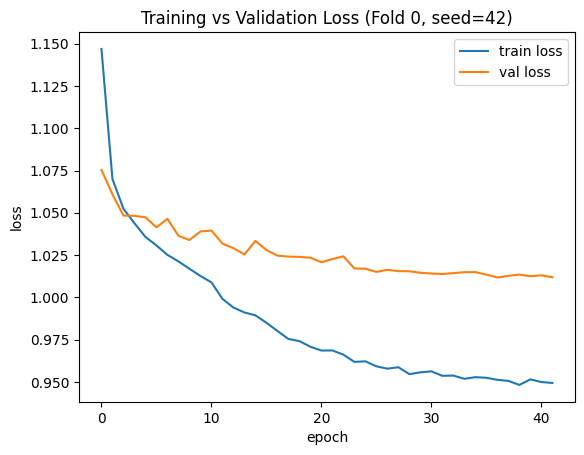

In [62]:
import matplotlib.pyplot as plt

hist0 = fold_histories[0].history  # Fixed variable name
plt.figure()
plt.plot(hist0["loss"], label="train loss")
plt.plot(hist0["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training vs Validation Loss (Fold 0, seed=42)")  # Fixed title
plt.show()

# Section 3: Tuning Hyper-parameters 
In this section, parameters including learning rate, weight decay and batch size will be tuned to explore their impacts on the model's performance. 

Stage 1: “big wins” search (capacity + LR + dropout)

Stage 2: fine tuning (regularisation / optimiser)

In [63]:
import itertools
import pandas as pd

def config_grid(base):
    """Generate grid of configurations to try"""
    hidden_list = [(128, 64), (256, 128), (128, 64, 32)]
    lr_list = [1e-3, 3e-4]
    dropout_list = [0.1, 0.3]

    for hu, lr, dr in itertools.product(hidden_list, lr_list, dropout_list):
        cfg = dict(base)
        cfg["hidden_units"] = hu
        cfg["lr"] = lr
        cfg["dropout"] = dr
        yield cfg

# Base configuration
base_config = {
    "hidden_units": (128, 64),
    "activation": "relu",
    "dropout": 0.2,
    "batchnorm": True,
    "l2": 1e-4,
    "init": "he_normal",

    "optimizer": "adamw",
    "lr": 1e-3,
    "weight_decay": 1e-4,

    "batch_size": 256,
    "max_epochs": 50,
    "patience": 5,
}

# =====================================
# PROPER APPROACH: Tune on FOLD 0 ONLY
# =====================================
print("=== Hyperparameter Tuning on Fold 0 ===\n")

# Get fold 0 data
train_idx, val_idx = folds[0]
X_train, Y_train = X[train_idx], y_onehot[train_idx]
X_val, Y_val = X[val_idx], y_onehot[val_idx]

# Normalize using training data only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8
X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std

tuning_results = []

for cfg in config_grid(base_config):
    # Train on fold 0 only with fixed seed 42
    model, hist, metrics = train_one_fold_keras(
        X_train_norm, Y_train, X_val_norm, Y_val,
        cfg, seed=42, verbose=0
    )
    
    tuning_results.append({
        "val_macro_f1": metrics["val_macro_f1"],
        "val_acc": metrics["val_acc"],
        "gap_macro_f1": metrics["gap_macro_f1"],
        "gap_loss": metrics["gap_loss"],
        "hidden_units": cfg["hidden_units"],
        "lr": cfg["lr"],
        "dropout": cfg["dropout"],
    })
    
    print(f"Config: hidden={cfg['hidden_units']}, lr={cfg['lr']}, dropout={cfg['dropout']} | "
          f"Val F1={metrics['val_macro_f1']:.4f}, Gap={metrics['gap_macro_f1']:.4f}")

# Sort by validation F1
df_tuning = pd.DataFrame(tuning_results).sort_values("val_macro_f1", ascending=False)

print("\n=== Top 5 Configurations (from Fold 0 tuning) ===")
display(df_tuning.head(5))

# Select best config
best_config_row = df_tuning.iloc[0]
best_config = dict(base_config)
best_config["hidden_units"] = best_config_row["hidden_units"]
best_config["lr"] = best_config_row["lr"]
best_config["dropout"] = best_config_row["dropout"]

print(f"\n=== Best Config Selected ===")
print(f"Hidden units: {best_config['hidden_units']}")
print(f"Learning rate: {best_config['lr']}")
print(f"Dropout: {best_config['dropout']}")

# =====================================
# NOW evaluate on ALL folds with best config
# =====================================
print("\n=== Evaluating Best Config on All 10 Folds ===\n")

df_gap, fold_models, fold_histories, fold_normalizations = run_kfold_cv_keras(
    X, y_onehot, folds, best_config, verbose=0
)

=== Hyperparameter Tuning on Fold 0 ===

Config: hidden=(128, 64), lr=0.001, dropout=0.1 | Val F1=0.4447, Gap=-0.0805
Config: hidden=(128, 64), lr=0.001, dropout=0.3 | Val F1=0.4377, Gap=-0.0531
Config: hidden=(128, 64), lr=0.0003, dropout=0.1 | Val F1=0.4411, Gap=-0.0428
Config: hidden=(128, 64), lr=0.0003, dropout=0.3 | Val F1=0.4363, Gap=-0.0330
Config: hidden=(256, 128), lr=0.001, dropout=0.1 | Val F1=0.4372, Gap=-0.0540
Config: hidden=(256, 128), lr=0.001, dropout=0.3 | Val F1=0.4414, Gap=-0.0914
Config: hidden=(256, 128), lr=0.0003, dropout=0.1 | Val F1=0.4448, Gap=-0.0685
Config: hidden=(256, 128), lr=0.0003, dropout=0.3 | Val F1=0.4423, Gap=-0.0373
Config: hidden=(128, 64, 32), lr=0.001, dropout=0.1 | Val F1=0.4456, Gap=-0.0584
Config: hidden=(128, 64, 32), lr=0.001, dropout=0.3 | Val F1=0.4420, Gap=-0.0349
Config: hidden=(128, 64, 32), lr=0.0003, dropout=0.1 | Val F1=0.4433, Gap=-0.0675
Config: hidden=(128, 64, 32), lr=0.0003, dropout=0.3 | Val F1=0.4375, Gap=-0.0208

=== Top 

,val_macro_f1,val_acc,gap_macro_f1,gap_loss,hidden_units,lr,dropout
8,0.445639,0.500315,-0.058427,0.044502,"(128, 64, 32)",0.0010,0.1
6,0.444800,0.497268,-0.068549,0.053753,"(256, 128)",0.0003,0.1
0,0.444716,0.499790,-0.080537,0.076304,"(128, 64)",0.0010,0.1
10,0.443271,0.494327,-0.067471,0.059671,"(128, 64, 32)",0.0003,0.1
7,0.442257,0.491805,-0.037271,0.023844,"(256, 128)",0.0003,0.3



=== Best Config Selected ===
Hidden units: (128, 64, 32)
Learning rate: 0.001
Dropout: 0.1

=== Evaluating Best Config on All 10 Folds ===

Fold 0: TrainF1=0.507  ValF1=0.430  Gap=-0.076 | TrainLoss=0.936  ValLoss=1.022
Fold 1: TrainF1=0.506  ValF1=0.430  Gap=-0.076 | TrainLoss=0.968  ValLoss=1.028
Fold 2: TrainF1=0.514  ValF1=0.449  Gap=-0.065 | TrainLoss=0.960  ValLoss=1.017
Fold 3: TrainF1=0.496  ValF1=0.438  Gap=-0.058 | TrainLoss=0.964  ValLoss=1.014
Fold 4: TrainF1=0.525  ValF1=0.448  Gap=-0.077 | TrainLoss=0.939  ValLoss=1.006
Fold 5: TrainF1=0.506  ValF1=0.445  Gap=-0.060 | TrainLoss=0.953  ValLoss=1.016
Fold 6: TrainF1=0.482  ValF1=0.439  Gap=-0.044 | TrainLoss=0.973  ValLoss=1.021
Fold 7: TrainF1=0.512  ValF1=0.449  Gap=-0.064 | TrainLoss=0.965  ValLoss=1.005
Fold 8: TrainF1=0.533  ValF1=0.439  Gap=-0.094 | TrainLoss=0.937  ValLoss=1.005
Fold 9: TrainF1=0.492  ValF1=0.458  Gap=-0.034 | TrainLoss=0.973  ValLoss=1.021

=== Gap summary (mean ± std) ===
      train_macro_f1  val

In [65]:
# ----------------------------
# A1) Define the FINAL config (from tuning)
# ----------------------------
final_config = {
    "hidden_units": (256, 128),
    "activation": "relu",
    "dropout": 0.3,
    "batchnorm": True,
    "l2": 1e-4,
    "init": "he_normal",

    "optimizer": "adamw",
    "lr": 0.0003,
    "weight_decay": 1e-4,

    "batch_size": 256,
    "max_epochs": 50,  # or 150 if you have time
    "patience": 12,
}

# ----------------------------
# A2) Run 10-fold CV with final config
# ----------------------------
print("=== Running 10-Fold CV with Final Config ===\n")

df_final, fold_models, fold_histories, fold_normalizations = run_kfold_cv_keras(
    X, y_onehot, folds,
    final_config,
    verbose=0
)

# ----------------------------
# A3) Display results
# ----------------------------
print("\n=== Per-Fold Results ===")
display(df_final[["fold", "val_macro_f1", "val_acc", "gap_macro_f1", "gap_loss"]])

print("\n=== FINAL 10-FOLD SUMMARY (Report this) ===")
print(f"Val Macro-F1: {df_final['val_macro_f1'].mean():.4f} ± {df_final['val_macro_f1'].std():.4f}")
print(f"Val Accuracy: {df_final['val_acc'].mean():.4f} ± {df_final['val_acc'].std():.4f}")
print(f"Gap Macro-F1: {df_final['gap_macro_f1'].mean():.4f} ± {df_final['gap_macro_f1'].std():.4f}")
print(f"Gap Loss: {df_final['gap_loss'].mean():.4f} ± {df_final['gap_loss'].std():.4f}")

=== Running 10-Fold CV with Final Config ===

Fold 0: TrainF1=0.521  ValF1=0.447  Gap=-0.073 | TrainLoss=0.969  ValLoss=1.021
Fold 1: TrainF1=0.518  ValF1=0.443  Gap=-0.074 | TrainLoss=0.969  ValLoss=1.026
Fold 2: TrainF1=0.513  ValF1=0.451  Gap=-0.062 | TrainLoss=0.993  ValLoss=1.016
Fold 3: TrainF1=0.524  ValF1=0.441  Gap=-0.084 | TrainLoss=0.960  ValLoss=1.013
Fold 4: TrainF1=0.515  ValF1=0.455  Gap=-0.060 | TrainLoss=0.963  ValLoss=1.012
Fold 5: TrainF1=0.510  ValF1=0.448  Gap=-0.063 | TrainLoss=0.970  ValLoss=1.021
Fold 6: TrainF1=0.511  ValF1=0.438  Gap=-0.072 | TrainLoss=0.961  ValLoss=1.016
Fold 7: TrainF1=0.539  ValF1=0.456  Gap=-0.083 | TrainLoss=0.952  ValLoss=1.004
Fold 8: TrainF1=0.522  ValF1=0.442  Gap=-0.080 | TrainLoss=0.961  ValLoss=1.014
Fold 9: TrainF1=0.506  ValF1=0.454  Gap=-0.052 | TrainLoss=0.973  ValLoss=1.017

=== Gap summary (mean ± std) ===
      train_macro_f1  val_macro_f1  gap_macro_f1  final_train_loss  \
mean        0.517919      0.447605     -0.070314  

,fold,val_macro_f1,val_acc,gap_macro_f1,gap_loss
0,0,0.447158,0.499054,-0.073366,0.052082
1,1,0.443325,0.497524,-0.074413,0.056632
2,2,0.450893,0.505860,-0.061910,0.022102
3,3,0.440660,0.494491,-0.083827,0.052314
4,4,0.455333,0.516415,-0.059686,0.048314
5,5,0.447805,0.500387,-0.062683,0.050473
6,6,0.438403,0.496045,-0.072195,0.054522
7,7,0.456183,0.512457,-0.083129,0.051834
8,8,0.442099,0.500443,-0.080014,0.052918
9,9,0.454188,0.507058,-0.051917,0.044286



=== FINAL 10-FOLD SUMMARY (Report this) ===
Val Macro-F1: 0.4476 ± 0.0064
Val Accuracy: 0.5030 ± 0.0073
Gap Macro-F1: -0.0703 ± 0.0108
Gap Loss: 0.0485 ± 0.0099


In [66]:
# Add detailed per-class metrics
from sklearn.metrics import classification_report
import pandas as pd

detailed_metrics = []

for fold_id, model in enumerate(fold_models):
    _, val_idx = folds[fold_id]
    X_val_raw = X[val_idx]
    Y_val = y_onehot[val_idx]
    
    # Apply normalization
    mean, std = fold_normalizations[fold_id]
    X_val_norm = (X_val_raw - mean) / std
    
    # Predict
    y_pred = np.argmax(model.predict(X_val_norm, verbose=0), axis=1)
    y_true = np.argmax(Y_val, axis=1)
    
    # Compute metrics
    from sklearn.metrics import precision_recall_fscore_support
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    _, _, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    
    detailed_metrics.append({
        "fold": fold_id,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "f1_weighted": f1_weighted
    })

df_detailed = pd.DataFrame(detailed_metrics)
print("\n=== Detailed Metrics ===")
display(df_detailed)
print(f"\nPrecision (macro): {df_detailed['precision_macro'].mean():.4f} ± {df_detailed['precision_macro'].std():.4f}")
print(f"Recall (macro): {df_detailed['recall_macro'].mean():.4f} ± {df_detailed['recall_macro'].std():.4f}")
print(f"F1 (weighted): {df_detailed['f1_weighted'].mean():.4f} ± {df_detailed['f1_weighted'].std():.4f}")


=== Detailed Metrics ===


,fold,precision_macro,recall_macro,f1_macro,f1_weighted
0,0,0.456357,0.475829,0.447158,0.521169
1,1,0.450897,0.471042,0.443325,0.519458
2,2,0.455386,0.471389,0.450893,0.524669
3,3,0.449875,0.472451,0.440660,0.517017
4,4,0.457822,0.473935,0.455333,0.533048
5,5,0.456658,0.479500,0.447805,0.522802
6,6,0.448971,0.465789,0.438403,0.519169
7,7,0.458116,0.479909,0.456183,0.530151
8,8,0.448360,0.464667,0.442099,0.521259
9,9,0.459071,0.477788,0.454188,0.526171



Precision (macro): 0.4542 ± 0.0042
Recall (macro): 0.4732 ± 0.0053
F1 (weighted): 0.5235 ± 0.0051
